# Lab 4.06 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 6 - Influence of background music on purchasing behaviour

Market research shows that background music in a supermarket can influence the purchasing behaviour of customers. A study compared three methods: no music, French chansons and Italian hits. In each case, the number of bottles of French, Italian and other wines sold was counted (Ryan, et al., 1998).

The research data can be found in the file data/MuziekWijn.csv.

1. Set up the correct crosstab.
2. Determine the marginal totals.
3. Determine the expected results.
4. Calculate the χ² test statistic.
5. Calculate Cramér's V. What can you conclude from this?

Visualize the data set:

1. Plot a bar chart showing the percentages of types of wine sold when no music was playing.
2. Plot a clustered bar chart of the dataset
3. Plot a bar chart (stacked bar chart) of the dataset

Results of the main calculations (rounded up to 3 decimal places):

* χ² ≈ 18.279
* Cramér's V ≈ 0.194

Read the dataset

In [6]:
df = pd.read_csv('../data/MuziekWijn.csv')
df.head(10)

,Muziek,Wijn
0,Geen,Franse
1,Franse,Franse
2,Franse,Italiaanse
3,Italiaanse,Andere
4,Italiaanse,Franse
5,Italiaanse,Andere
6,Geen,Franse
7,Geen,Andere
8,Geen,Franse
9,Geen,Italiaanse


Give the names of both columns. What is wrong?

In [7]:
df.columns

Index(['Muziek', ' Wijn'], dtype='str')

You can change the name of a column 'ab' to the column 'abc' of the dataframe df, using the following command

`df = df.rename(columns={'ab': 'abc'})`

Use this command to change the column name.  
Check afterwards if the result is correct.

In [8]:
df = df.rename(columns={' Wijn': 'Wijn'})
df.columns

Index(['Muziek', 'Wijn'], dtype='str')

1. Set up the correct crosstab.

In [16]:
observed = pd.crosstab(df['Wijn'], df['Muziek'])
observed

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,35,43,35
Franse,39,30,30
Italiaanse,1,11,19


2. Determine the marginal totals.

In [22]:
row_sum = observed.sum(axis=1)
col_sum = observed.sum()
print(row_sum)
print(col_sum)

Wijn
Andere        113
Franse         99
Italiaanse     31
dtype: int64
Muziek
Franse        75
Geen          84
Italiaanse    84
dtype: int64


3. Determine the expected results.

In [26]:
n = len(df)
expected = np.outer(row_sum, col_sum) / n
expected

array([[34.87654321, 39.0617284 , 39.0617284 ],
       [30.55555556, 34.22222222, 34.22222222],
       [ 9.56790123, 10.71604938, 10.71604938]])

4. Calculate the χ² test statistic.

In [27]:
diff = observed - expected
diff

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,0.123457,3.938272,-4.061728
Franse,8.444444,-4.222222,-4.222222
Italiaanse,-8.567901,0.283951,8.283951


In [28]:
diff **= 2
diff

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,0.015242,15.509983,16.497638
Franse,71.308642,17.827160,17.827160
Italiaanse,73.408932,0.080628,68.623838


In [29]:
diff /= expected
diff

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,0.000437,0.397063,0.422348
Franse,2.333737,0.520924,0.520924
Italiaanse,7.672417,0.007524,6.403837


In [36]:
chi2 = diff.sum().sum()
chi2 = chi2.round(3)
chi2

np.float64(18.279)

In [37]:
chi2, p, dof, expected = stats.chi2_contingency(observed)
chi2 = chi2.round(3)
print(chi2)
print(expected)

18.279
[[34.87654321 39.0617284  39.0617284 ]
 [30.55555556 34.22222222 34.22222222]
 [ 9.56790123 10.71604938 10.71604938]]


5. Calculate Cramér's V. What can you conclude from this?

In [49]:
dof = min(diff.shape) - 1
v = np.sqrt(chi2/(n * dof))
v = v.sum().sum().round(3)
v

np.float64(0.194)

In [52]:
v = stats.contingency.association(observed, method='cramer')
v = np.round(v, 3)
v

np.float64(0.194)

The value of Cramers V is low so there is weak to moderate association between playing music and buying wine

Plot a bar chart showing the percentages of types of wine sold when no music was playing.

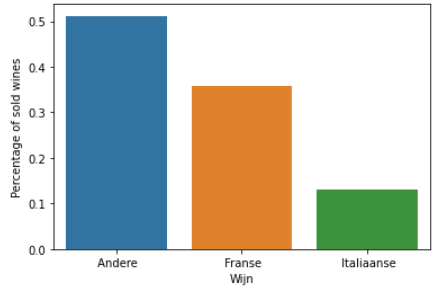

In [ ]:
observed

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,35,43,35
Franse,39,30,30
Italiaanse,1,11,19


In [65]:
observed.Geen

Wijn
Andere        43
Franse        30
Italiaanse    11
Name: Geen, dtype: int64

<Axes: xlabel='Wijn'>

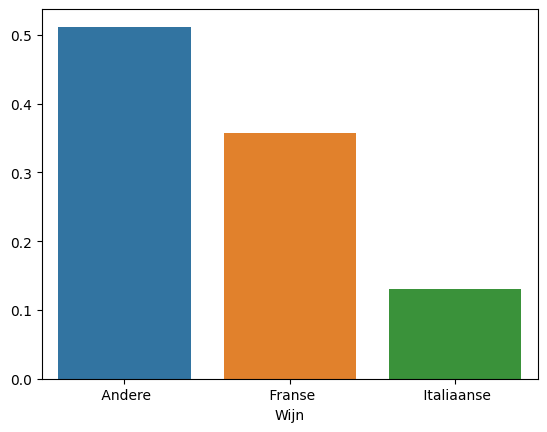

In [82]:
data = observed.Geen / observed.Geen.sum()
sns.barplot(x=data.index, y=data.values, hue=data.index)

Plot a clustered bar chart of the dataset  

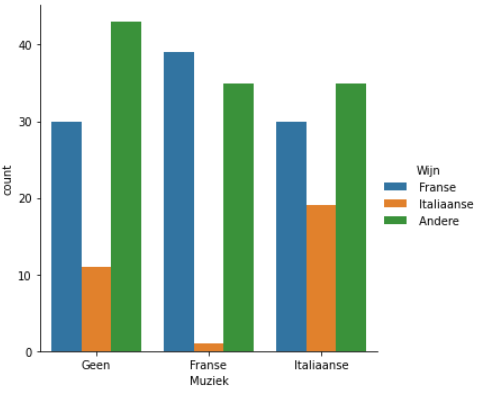

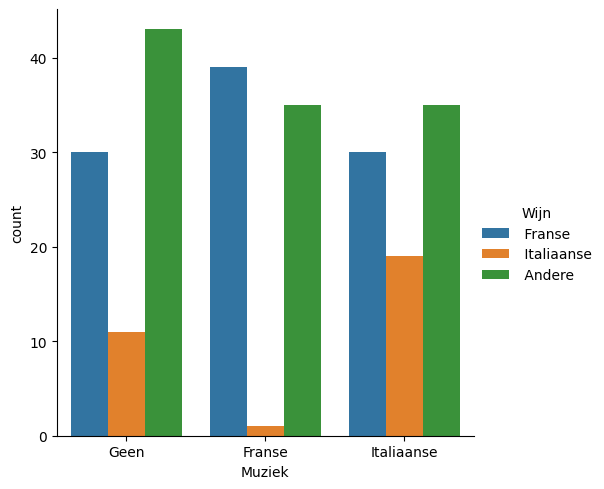

In [83]:
sns.catplot(data=df, x='Muziek', hue='Wijn', kind='count');

Plot a bar chart (stacked bar chart) of the dataset

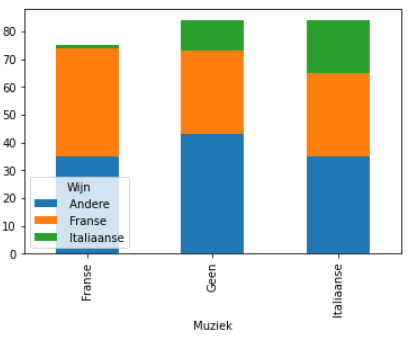

<Axes: xlabel='Muziek'>

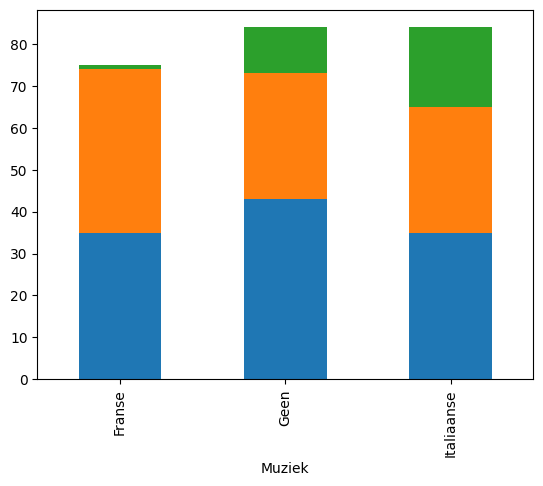

In [94]:
observed2 = pd.crosstab(df.Muziek, df.Wijn)
observed2.plot(kind='bar', stacked=True, legend=False)